# Laboratorio 6 - Parte 1: Reducción de dimensión y Selección de características

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

In [ ]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L06.01", varname="student");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [2]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab6 import *
_, x, y = part_1()

Este ejercicio tiene como objetivo implementar varias técnicas de selección de características y usar regresion logística para resolver un problema de clasificación multiclase.

Para el problema de clasificación usaremos la siguiente base de datos: https://archive.ics.uci.edu/ml/datasets/Cardiotocography

Analice la base de datos, sus características, su variable de salida y el contexto del problema.

In [3]:
print('Dimensiones de la base de datos de entrenamiento. dim de x: ' + str(np.shape(x)) + '\tdim de y: ' + str(np.shape(y)))

Dimensiones de la base de datos de entrenamiento. dim de x: (2126, 22)	dim de y: (2126,)


In [4]:
print('Dimensiones de la base de datos de entrenamiento. Dim de x: ' + str(np.shape(x)) + '\tDim de y: ' + str(np.shape(y)))

clases, muestras_por_clase = np.unique(y, return_counts=True)
print("las clases son", clases, "el conteo",muestras_por_clase)

Dimensiones de la base de datos de entrenamiento. Dim de x: (2126, 22)	Dim de y: (2126,)
las clases son [1 2 3] el conteo [1655  295  176]


**Observación para las librerias sklearn**

Llamar explícitamente los parametros de las librerias de sklearn (e.j. si se quiere usar el parametro `kernel` del `SVC`, se debe llamar `SVC(kernel='rbf'`))

### Ejercicio 1: Entrenamiento sin selección de características

En nuestro primer ejercicio debemos completar la función para entrenar una SVM para resolver un problema de clasificación. Debemos completar siguiendo las recomendaciones:

1. Mantener los parámetros sugeridos de la regresión logística.
2. Asignar el parametro de StratifiedKFold a los splits
3. Usar la area bajo la curva ROC como medida de error del modulo [metrics de sklearn](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics). Tener en cuenta que esta función recibe un score, que es diferente a la predicción (explorar que método debemos usar para nuestro caso de problema y usar un estrategia One vs One).
4. Esta función la vamos a usar como base para comparar nuestros métodos de selección de características.

In [ ]:
#ejercicio de código
def entrenamiento_sin_seleccion_caracteristicas(X, Y, splits):
    """
    Función que ejecuta el entrenamiento del modelo sin una selección particular
    de las características

      Parámetros:
        X: matriz con las características
        Y: Matriz con la variable objetivo
        splits : número de particiones  a realizar

      Retorna:
      1. El modelo entreando
      2. El vector de errores
      3. El Intervalo de confianza
      4. El tiempo de procesamiento
    """

    j = 0
    kf = StratifiedKFold...
    clases = ...

    for train_index, test_index in kf.split(X=X, y=Y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = Y[train_index], Y[test_index]

        # Escalado
        scaler = StandardScaler()
        X_train = ...
        X_test = ...

        # Clasificador SVM
        clf = SVC(..., random_state=42)

        # Entrenamiento el modelo.
        # Para calcular el costo computacional
        tiempo_i = time.time()
        clf.fit(X=X_train,y=y_train)

        # Scores para ROC AUC
        y_score = clf.decision_function(X_test)
        y_test_bin = label_binarize(y_test, classes=clases)

        # Scores para ROC AUC
        y_score = ...
        y_test_bin = label_binarize(y_test, classes=clases)

        # Cálculo del AUC con estrategia One-vs-One
        auc = roc_auc_score....

        Errores[j] = auc
        times[j] = time.time() - tiempo_i
        j += 1

    return ...

In [5]:
## TEACHER
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L06.01", varname="teacher");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [6]:
## TEACHER DEFINEGRADER
def grader_01(functions, variables, caller_userid):
    import numpy as np
    import time
    from sklearn.model_selection import StratifiedKFold
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler, label_binarize
    from sklearn.metrics import confusion_matrix, roc_auc_score
    from sklearn.svm import SVC

    def t_entrenamiento_sin_seleccion_caracteristicas(X, Y, splits):
        #Implemetamos la metodología de validación
        rendimiento = np.ones(splits)
        times = np.ones(splits)
        j = 0
        kf = StratifiedKFold(n_splits = splits,shuffle=True, random_state=42)
        clases = np.unique(Y)

        for train_index, test_index in kf.split(X=X, y=Y):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = Y[train_index], Y[test_index]

            # Escalado
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # Clasificador SVM
            clf = SVC(kernel="linear", probability=True, decision_function_shape="ovo", random_state=42)

            # Entrenamiento el modelo.
            # Para calcular el costo computacional
            tiempo_i = time.time()
            clf.fit(X=X_train,y=y_train)

            # Scores para ROC AUC
            y_score = clf.decision_function(X_test)
            y_test_bin = label_binarize(y_test, classes=clases)

            # Scores para ROC AUC
            y_score = clf.decision_function(X_test)
            y_test_bin = label_binarize(y_test, classes=clases)

            # Cálculo del AUC con estrategia One-vs-One
            auc = roc_auc_score(y_test_bin, y_score, multi_class="ovo", average="macro")

            rendimiento[j] = auc
            times[j] = time.time() - tiempo_i
            j += 1
        # RENDIMIENTO_VALIDACION, STD_RENDIMIENTO_VALIDACION, TIEMPO_EJECUCION
        return clf, np.mean(rendimiento), np.std(rendimiento), np.mean(times)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_entrenamiento_sin_seleccion_caracteristicas = namespace['entrenamiento_sin_seleccion_caracteristicas']

    msg = "testing your code with random data points<br/>"

    for _ in range(5):

      num_samples  = np.random.randint(500) + 20
      num_features = np.random.randint(10) + 2
      splits = 5  # Número de particiones

      X = np.random.randn(num_samples, num_features)  # Matriz de características
      Y = np.random.choice([0, 1], size=num_samples)  # Clases binarias

      msg = ""
              # Ejecutar la función de referencia y la del usuario
      try:
          _, t_err, t_ic, t_ex = t_entrenamiento_sin_seleccion_caracteristicas(X, Y, splits)
          _, s_err, s_ic, s_ex = s_entrenamiento_sin_seleccion_caracteristicas(X, Y, splits)
      except Exception as e:
          return 0, f"Error al ejecutar la función: {str(e)}"

      if not np.allclose(t_err, s_err, atol=1e-2):
          msg += f"Rendimiento esperado: {t_err},     obtenido: {s_err}<br/>"
          return 0, msg

      if not np.allclose(t_ic, s_ic, atol=1e-2):
          msg += f"Desviación estándar esperada: {t_ic},     obtenida: {s_ic}<br/>"
          return 0, msg

      if not np.allclose(t_ex, s_ex, atol=1e-2):
          msg += f"Tiempo esperado: {t_ex},     obtenido: {s_ex}<br/>"
          return 0, msg


      return 5, msg+'<b>correct</b>'
source_functions_names_01 = ['entrenamiento_sin_seleccion_caracteristicas']
source_variables_names_01 = []

In [7]:
## TEACHER
def entrenamiento_sin_seleccion_caracteristicas(X, Y, splits):
    import numpy as np
    from sklearn.model_selection import StratifiedKFold
    from sklearn.preprocessing import StandardScaler, label_binarize
    from sklearn.metrics import confusion_matrix, roc_auc_score
    from sklearn.svm import SVC

    #Implemetamos la metodología de validación
    errores = np.ones(splits)
    times = np.ones(splits)
    j = 0
    kf = StratifiedKFold(n_splits = splits,shuffle=True, random_state=42)
    clases = np.unique(Y)

    for train_index, test_index in kf.split(X=X, y=Y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = Y[train_index], Y[test_index]

        # Escalado
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Clasificador SVM
        clf = SVC(kernel="linear", probability=True, decision_function_shape="ovo", random_state=42)

        # Entrenamiento el modelo.
        # Para calcular el costo computacional
        tiempo_i = time.time()
        clf.fit(X=X_train,y=y_train)

        # Scores para ROC AUC
        y_score = clf.decision_function(X_test)
        y_test_bin = label_binarize(y_test, classes=clases)

        # Scores para ROC AUC
        y_score = clf.decision_function(X_test)
        y_test_bin = label_binarize(y_test, classes=clases)

        # Cálculo del AUC con estrategia One-vs-One
        auc = roc_auc_score(y_test_bin, y_score, multi_class="ovo", average="macro")

        errores[j] = auc
        times[j] = time.time() - tiempo_i
        j += 1

    return clf, np.mean(errores), np.std(errores), np.mean(times)

In [8]:
## TEACHER
import inspect
teacher.run_grader_locally("grader_01", source_functions_names_01, source_variables_names_01, locals())

In [9]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L06.01", 'T1',
                  inspect.getsource(grader_01), 'grader_01',
                  source_functions_names_01, source_variables_names_01)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T1');

In [ ]:
#@markdown En sus palabras ¿Cuál es el proceso ejecutado por la función roc_auc_score que calcula la área sobre la curva roc?
respuesta = '' #@param {type:"string"}

## Ejercicio 2: Entrenamiento con selección de características

La siguiente función "wrapper" nos permite hacer una selección de características utilizando la [librería recursive feature elimination de Sci-kit Learn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html).

Esta librería es un método de selección características wrapper, que usa los coeficientes derivados de  un estimador entrenado para estimar que características tienen mayor poder predictivo.

Para completar debemos tener en cuenta lo siguiente:

1. Para el número de características usar el parámetro feature_numbers
2. Establecer el paso = 1 para ir eliminando las características
3. Asumir que el estimador se crea externamente de la función
4. Entender los campos del RFE disponibles despues de entrenarlo para obtener:
    1. La máscara para saber que características fueron seleccionadas
    2. El ranking de las características
5. Usar como estimador regresión de vectores de soporte (SVR) como estimador

In [ ]:
#ejercicio de código
def recursive_feature_elimination_wrapper(estimator, feature_numbers, X,Y):
    """
    Esta función es un envoltorio del objeto RFE de sklearn

    Parámetros:
    estimator: un modelo entregado como parámetro
    feature_numbers(int): el número de características a considerar
    X (numpy.array): el arreglo numpy de muestras de entrada
    Y (numpy.array): el vector de etiquetas correspondiente

    Retorna:
    El modelo entrenado
    La máscara de características seleccionada, array [longitud de caracterisitcas de X]
    El ranking de características, array [longitud de caracterisitcas de X]
    El objeto RFE entrenado sobre el set reducido de características
    El tiempo de ejecución
    """
    rfe = ...(estimator=..., n_features_to_select=..., step=...)
    tiempo_i = time.time()
    rfe.fit...
    time_o = time.time()-tiempo_i
    feature_mask = rfe...
    features_rank = rfe...
    estimator = rfe...

    return rfe, feature_mask, features_rank, estimator, time_o

In [34]:
## TEACHER DEFINEGRADER
def grader_02(functions, variables, caller_userid):
    import numpy as np
    import time
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_selection import RFE
    from sklearn.svm import SVC

    def t_recursive_feature_elimination_wrapper(estimator, feature_numbers, X,Y):
        rfe = RFE(estimator=estimator , n_features_to_select=feature_numbers , step=1)
        tiempo_i = time.time()
        rfe.fit(X=X , y= Y)
        time_o = time.time()-tiempo_i
        feature_mask = rfe.support_
        features_rank = rfe.ranking_
        estimator = rfe.estimator_

        return rfe, feature_mask, features_rank, estimator, time_o

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_recursive_feature_elimination_wrapper = namespace['recursive_feature_elimination_wrapper']

    msg = "testing your code with random data points<br/>"

    for _ in range(5):

      num_samples  = np.random.randint(500) + 20
      num_features = np.random.randint(10) + 2

      X = np.random.randn(num_samples, num_features)  # Matriz de características
      Y = np.random.choice([0, 1], size=num_samples)
      estimator = SVC(kernel="linear") #LogisticRegression(solver="liblinear")
      msg = ""
              # Ejecutar la función de referencia y la del usuario
      try:
          _, t_mask, t_rank, t_estimator, t_time = t_recursive_feature_elimination_wrapper(estimator, num_features, X, Y)
          _, s_mask, s_rank, s_estimator, s_time = s_recursive_feature_elimination_wrapper(estimator, num_features, X, Y)
      except Exception as e:
          return 0, f"Error al ejecutar la función: {str(e)}"

      if not np.array_equal(t_mask, s_mask):
          msg += f"Máscara esperada: {t_mask}, obtenida: {s_mask}<br/>"
          return 0, msg

      if not np.array_equal(t_rank, s_rank):
          msg += f"Ranking esperado: {t_rank}, obtenido: {s_rank}<br/>"
          return 0, msg

      if not np.allclose(t_time, s_time, atol=1e-2):
          msg += f"Tiempo esperado: {t_time}, obtenido: {s_time}<br/>"
          return 0, msg


      return 5, msg+'<b>correct</b>'
source_functions_names_02 = ['recursive_feature_elimination_wrapper']
source_variables_names_02 = []

In [35]:
## TEACHER
def recursive_feature_elimination_wrapper(estimator, feature_numbers, X,Y):

    rfe = RFE(estimator=estimator , n_features_to_select=feature_numbers , step=1)
    tiempo_i = time.time()
    rfe.fit(X=X , y= Y)
    time_o = time.time()-tiempo_i
    feature_mask = rfe.support_
    features_rank = rfe.ranking_
    estimator = rfe.estimator_

    return rfe, feature_mask, features_rank, estimator, time_o

In [36]:
## TEACHER
import inspect
teacher.run_grader_locally("grader_02", source_functions_names_02, source_variables_names_02, locals())

In [37]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L06.01", 'T2',
                  inspect.getsource(grader_02), 'grader_02',
                  source_functions_names_02, source_variables_names_02)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T2');

In [18]:
#@title Preguntas Abierta
#@markdown Explicar ¿Qué diferencia tiene el método implementado con un método que usa un criterio tipo filtro para la selección de características?
respuesta = '' #@param {type:"string"}

## Ejercicio 3:  Comparación de los resultados del modelo

Ahora en la siguiente función, vamos a usar la función planteada para realizar experimentos con la selección de características. Para ello:
1. Utilizar una metodología cross-validation estratificada.
2. Considerando p características, retorne el modelo entrenado, el vector de errores, el intervalo de confianza y el tiempo de ejecución.
3. Vamos a retornar un DataFrame con las siguientes columnas:
    - CON_SEL: indicando si se uso selección de características
    - NUM_VAR: número de selección de características
    - NUM_SPLITS: número de particiones realizadas
    - T_EJECUCION: tiempo de ejecución
    - EXACTITUD_BALANCEADA
    - STD_EXACTITUD_BALANCEADA

4. En la primera fila del dataframe vamos a incluir la evaluación del modelo SVM sin selección de características (usando la función creada en el primer ejercicio) y sin particionar el set de datos.

In [19]:
#ejercicio de código
def experimentar(n_feats, n_sets, X, Y):
    """
    Esta función realiza la comparación del desempeño de RFE utilizando diferente
    número de feats y particionando el conjunto de datos en diferente número de
    subconjuntos

    Parámetros:
    X (numpy.array), El arreglo numpy de características
    Y (numpy.array), El vector de etiquetas
    n_feats, Vector de números enteros que indica el número de características
              que debe utilizar el modelo
    n_sets, Vector de números enteros que indica el número de particiones

    Retorna:
    - DataFrame con las columnas: DESCRIPCION, T_EJECUCION ERROR_VALIDACION,
    y STD_ERROR_VALIDACION

    """
    df = pd.DataFrame()
    idx = 0
    for split_number in n_sets:
    #Sin selección de características
        # se ignorar las otras salidas
        _,err,ic,t_ex = entrenamiento_sin_seleccion_caracteristicas(...)

        df.loc[idx,'CON_SEL'] = 'NO'
        df.loc[idx,'NUM_VAR'] = X.shape[1]
        df.loc[idx,'NUM_SPLITS'] = ...
        df.loc[idx,'TIEMPO_EJECUCION'] = ...
        df.loc[idx,'EXACTITUD_BALANCEADA'] = ...
        df.loc[idx,'EXACTITUD_BALANCEADA'] = ...
        idx+=1
    print("termina experimentos sin selección")
    #Con selección de características
    for f in n_feats:
        for split_number in n_sets:
            #Implemetamos la metodología de validación
            Errores = np.ones(split_number)
            Score = np.ones(split_number)
            times = np.ones(split_number)
            kf = ...(n_splits=split_number)
            j = 0
            for train_index, test_index in kf.split(...,...):

                X_train, X_test = X[train_index], X[test_index]
                y_train, y_test = Y[train_index], Y[test_index]
                scaler = ...
                X_train = ...
                X_test = ...

                #Configure el modelo SVM para que usa un kernel lineal,
                #retorne probabilidades, use una estrategia all vs all y
                #ajuste la semilla a 0.
                clf =  SVM...

                # se ignorar las otras salidas
                rfe, _, _, _, t = recursive_feature_elimination_wrapper...
                Errores[j]=...
                times[j] = t
                j+=1

            df.loc[idx,'CON_SEL'] = 'SI'
            df.loc[idx,'NUM_VAR'] = f
            df.loc[idx,'NUM_SPLITS'] = ...
            df.loc[idx, 'TIEMPO_EJECUCION'] = ...
            df.loc[idx,'EXACTITUD_BALANCEADA'] = ...
            df.loc[idx, 'STD_EXACTITUD_BALANCEADA'] = ...
            idx+=1
    return df


SyntaxError: invalid syntax (<ipython-input-19-0930fb039012>, line 52)

In [41]:
## TEACHER DEFINEGRADER
def grader_03(functions, variables, caller_userid):
    import numpy as np
    import pandas as pd
    import time
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_selection import RFE
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import confusion_matrix, balanced_accuracy_score
    from sklearn.svm import SVC

    def t_experimentar(n_feats, n_sets, X, Y):
        df = pd.DataFrame()
        idx = 0
        # Sin selección de características
        for split_number in n_sets:
            _, err, ic, t_ex = entrenamiento_sin_seleccion_caracteristicas(X=X, Y=Y, splits=split_number)
            df.loc[idx, 'CON_SEL'] = 'NO'
            df.loc[idx, 'NUM_VAR'] = X.shape[1]
            df.loc[idx, 'NUM_SPLITS'] = split_number
            df.loc[idx, 'TIEMPO_EJECUCION'] = t_ex
            df.loc[idx, 'EXACTITUD_BALANCEADA'] = err
            df.loc[idx, 'STD_EXACTITUD_BALANCEADA'] = ic
            idx += 1

        # Con selección de características
        for features in n_feats:
            for split_number in n_sets:
                rendimiento = np.ones(split_number)
                times = np.ones(split_number)
                kf = StratifiedKFold(n_splits=split_number)
                j = 0
                for train_index, test_index in kf.split(X, Y):
                    X_train, X_test = X[train_index], X[test_index]
                    y_train, y_test = Y[train_index], Y[test_index]

                    scaler = StandardScaler()
                    X_train = scaler.fit_transform(X=X_train)
                    X_test = scaler.transform(X=X_test)

                    clf = SVC(kernel="linear", probability=True, decision_function_shape="ovo", random_state=0)

                    rfe, _, _, _, t = recursive_feature_elimination_wrapper(
                        estimator=clf,
                        feature_numbers=features,
                        X=X_train,
                        Y=y_train
                    )

                    ypred = rfe.predict(X=X_test)

                    # Evaluación para multiclase usando balanced accuracy
                    rendimiento[j] = balanced_accuracy_score(y_test, ypred)
                    times[j] = t
                    j += 1

                df.loc[idx, 'CON_SEL'] = 'SI'
                df.loc[idx, 'NUM_VAR'] = features
                df.loc[idx, 'NUM_SPLITS'] = split_number
                df.loc[idx, 'TIEMPO_EJECUCION'] = np.mean(times)
                df.loc[idx, 'EXACTITUD_BALANCEADA'] = np.mean(rendimiento)
                df.loc[idx, 'STD_EXACTITUD_BALANCEADA'] = np.std(rendimiento)
                idx += 1

        return df

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experimentar = namespace['experimentar']
    entrenamiento_sin_seleccion_caracteristicas = namespace['entrenamiento_sin_seleccion_caracteristicas']
    recursive_feature_elimination_wrapper = namespace['recursive_feature_elimination_wrapper']

    msg = "testing your code with random data points<br/>"

    for _ in range(5):

      num_samples  = np.random.randint(500) + 20
      num_features = np.random.randint(10) + 2
      n_feats = [1, 2, 3]  # número de características seleccionadas
      n_sets = [2, 3, 5]   # números de splits

      X = np.random.randn(num_samples, num_features)  # Matriz de características
      Y = np.random.choice([0, 1], size=num_samples)  # Clases binarias

      msg = ""
              # Ejecutar la función de referencia y la del usuario
      try:
          t_df = t_experimentar(n_feats, n_sets, X, Y)
          s_df = s_experimentar(n_feats, n_sets, X, Y)
      except Exception as e:
          return 0, f"Error al ejecutar la función: {str(e)}"

      # 1️⃣ Verificar que tengan la misma forma (filas y columnas)
      if t_df.shape != s_df.shape:
          return 0, f"Error: La forma del DataFrame no coincide.<br/>" \
                    f"🔹 <b>Esperado:</b> {t_df.shape}<br/>" \
                    f"🔹 <b>Obtenido:</b> {s_df.shape}<br/>"

      # 2️⃣ Verificar que tengan las mismas columnas
      missing_cols = set(t_df.columns) - set(s_df.columns)
      extra_cols = set(s_df.columns) - set(t_df.columns)

      if missing_cols:
          return 0, f"Faltan columnas en el resultado del usuario: {missing_cols}."
      if extra_cols:
          return 0, f"Hay columnas extra en el resultado del usuario: {extra_cols}."

      # 3️⃣ Verificar los tipos de datos de las columnas
      for column in t_df.columns:
          if t_df[column].dtype != s_df[column].dtype:
              return 0, f"Error en la columna <b>{column}</b>:<br/>" \
                        f"🔹 <b>Tipo esperado:</b> {t_df[column].dtype}<br/>" \
                        f"🔹 <b>Tipo obtenido:</b> {s_df[column].dtype}<br/>"

      # 4️⃣ Comparar los valores con una tolerancia del 5%
      tolerancia = 0.05
      for column in t_df.columns:
          if np.issubdtype(t_df[column].dtype, np.number):  # Solo comparar columnas numéricas
              diff = np.abs(t_df[column] - s_df[column])
              max_diff = diff.max()
              if (diff > tolerancia).any():
                  idx_error = diff.idxmax()  # Encontrar el índice donde hay mayor diferencia
                  return 0, f"⚠️ Diferencias significativas en la columna <b>{column}</b>:<br/>" \
                            f"🔹 <b>Esperado:</b> {t_df[column][idx_error]}<br/>" \
                            f"🔹 <b>Obtenido:</b> {s_df[column][idx_error]}<br/>" \

      msg += "<b>Correcto</b>: La implementación genera el DataFrame esperado.<br/>"


      return 5, msg
source_functions_names_03 = ['experimentar','entrenamiento_sin_seleccion_caracteristicas','recursive_feature_elimination_wrapper']
source_variables_names_03 = []

In [42]:
## TEACHER
def experimentar(n_feats, n_sets, X, Y):
    import numpy as np
    import pandas as pd
    import time
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_selection import RFE
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import confusion_matrix, balanced_accuracy_score
    from sklearn.svm import SVC

    df = pd.DataFrame()
    idx = 0

    # Sin selección de características
    for split_number in n_sets:
        _, err, ic, t_ex = entrenamiento_sin_seleccion_caracteristicas(X=X, Y=Y, splits=split_number)
        df.loc[idx, 'CON_SEL'] = 'NO'
        df.loc[idx, 'NUM_VAR'] = X.shape[1]
        df.loc[idx, 'NUM_SPLITS'] = split_number
        df.loc[idx, 'TIEMPO_EJECUCION'] = t_ex
        df.loc[idx, 'EXACTITUD_BALANCEADA'] = err
        df.loc[idx, 'STD_EXACTITUD_BALANCEADA'] = ic
        idx += 1

    # Con selección de características
    for features in n_feats:
        for split_number in n_sets:
            rendimiento = np.ones(split_number)
            times = np.ones(split_number)
            kf = StratifiedKFold(n_splits=split_number)
            j = 0
            for train_index, test_index in kf.split(X, Y):
                X_train, X_test = X[train_index], X[test_index]
                y_train, y_test = Y[train_index], Y[test_index]

                scaler = StandardScaler()
                X_train = scaler.fit_transform(X=X_train)
                X_test = scaler.transform(X=X_test)

                clf = SVC(kernel="linear", probability=True, decision_function_shape="ovo", random_state=0)

                rfe, _, _, _, t = recursive_feature_elimination_wrapper(
                    estimator=clf,
                    feature_numbers=features,
                    X=X_train,
                    Y=y_train
                )

                ypred = rfe.predict(X=X_test)

                # Evaluación para multiclase usando balanced accuracy
                rendimiento[j] = balanced_accuracy_score(y_test, ypred)
                times[j] = t
                j += 1

            df.loc[idx, 'CON_SEL'] = 'SI'
            df.loc[idx, 'NUM_VAR'] = features
            df.loc[idx, 'NUM_SPLITS'] = split_number
            df.loc[idx, 'TIEMPO_EJECUCION'] = np.mean(times)
            df.loc[idx, 'EXACTITUD_BALANCEADA'] = np.mean(rendimiento)
            df.loc[idx, 'STD_EXACTITUD_BALANCEADA'] = np.std(rendimiento)
            idx += 1

    return df

In [44]:
## TEACHER
import inspect
teacher.run_grader_locally("grader_03", source_functions_names_03, source_variables_names_03, locals())

In [45]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L06.01", 'T3',
                  inspect.getsource(grader_03), 'grader_03',
                  source_functions_names_03, source_variables_names_03)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T3');

Ejecuta la celda de codigo para realizar los experimentos

In [46]:
dfr = experimentar(n_feats = [3, 5, 10,15,20], n_sets = [3,6], X= x, Y=y)

Utilizando el *DataFrame* definido en la función anterior, retorne la mejor configuración del "Número de características" que resultó ,as beneficiosa. Identifique en términos de "Costo computacional" y "Eficiencia del Modelo".

In [47]:
# podemos cambiar las forma de organizar el df para observar qué diferencias hay
# cuando se cambia  la prioridad de alguno de los dos parámetros
dfr.sort_values(['EXACTITUD_BALANCEADA', "TIEMPO_EJECUCION"], ascending=[False, True])

,CON_SEL,NUM_VAR,NUM_SPLITS,TIEMPO_EJECUCION,EXACTITUD_BALANCEADA,STD_EXACTITUD_BALANCEADA
10,SI,20.0,3.0,0.326662,0.850994,0.043400
6,SI,10.0,3.0,1.301425,0.848227,0.043263
11,SI,20.0,6.0,0.460530,0.844635,0.064085
9,SI,15.0,6.0,1.384228,0.842403,0.061451
8,SI,15.0,3.0,0.828572,0.837961,0.044207
7,SI,10.0,6.0,2.054654,0.830788,0.086155
5,SI,5.0,6.0,2.630600,0.811788,0.127368
4,SI,5.0,3.0,2.110540,0.798087,0.100780
3,SI,3.0,6.0,2.779737,0.757735,0.118689
2,SI,3.0,3.0,2.205654,0.724338,0.098574


Veamos como se relaciona el tiempo de ejecución con los splits y la selección de caracteristicas

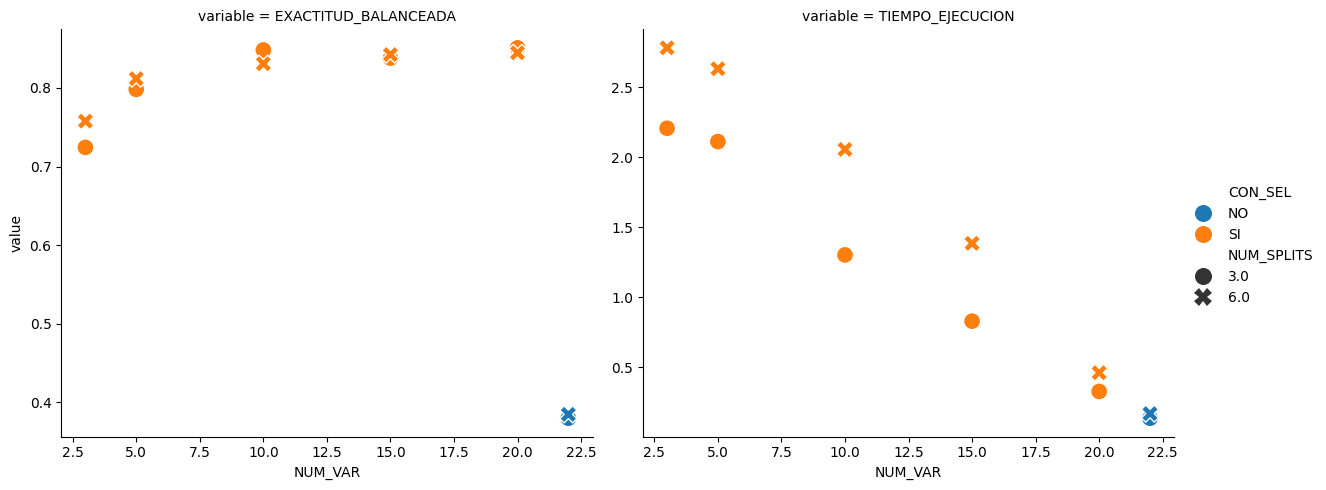

In [49]:
import seaborn as sns
d_toplot = pd.melt(dfr,id_vars=['CON_SEL', 'NUM_VAR', 'NUM_SPLITS'], value_vars=['EXACTITUD_BALANCEADA', 'TIEMPO_EJECUCION'])
sns.relplot(data = d_toplot,
    x = 'NUM_VAR',
    y = 'value',
    hue = 'CON_SEL',
    style = 'NUM_SPLITS',
    col = 'variable',
    kind='scatter',
    facet_kws = {'sharey' : False},
    aspect=1.2,
    s=150)
plt.show()

Ahora use el mejor modelo para entrenar nuevamente el modelo y saber que caracteristicas tienen el mejor poder predictivo. Use el # de caracteristicas que resulto mejor cuando se realizo alguna selección de caracteristicas.

In [50]:
# observemos el mejor modelo cuando se realizo selección de caracteristicas
dfr[dfr['CON_SEL'] == 'SI'].sort_values(["EXACTITUD_BALANCEADA"], ascending=[False]).head(2)

,CON_SEL,NUM_VAR,NUM_SPLITS,TIEMPO_EJECUCION,EXACTITUD_BALANCEADA,STD_EXACTITUD_BALANCEADA
10,SI,20.0,3.0,0.326662,0.850994,0.043400
6,SI,10.0,3.0,1.301425,0.848227,0.043263


**Ahora, completa la siguiente celda de código, para incluir la selección de características, con el número encontrado anteriormente**

In [ ]:
clf = SVC(...)#Use la misma configuración establecida en la anterior función experimentar
rfe, feature_mask, _, _, _ = recursive_feature_elimination_wrapper(clf, 10 , x,y)

mask_explicada = "\n".join([f"feature {i+1} : {m}" for i,m in zip(range(x.shape[1]), feature_mask)])

print(f"Esta es la máscara (debería contener solo valores True y False) \n {mask_explicada}")

Esta es la máscara (debería ser solo valores True y False) 
 feature 1 : True
feature 2 : True
feature 3 : False
feature 4 : False
feature 5 : True
feature 6 : False
feature 7 : True
feature 8 : False
feature 9 : True
feature 10 : False
feature 11 : False
feature 12 : False
feature 13 : False
feature 14 : False
feature 15 : True
feature 16 : True
feature 17 : False
feature 18 : True
feature 19 : False
feature 20 : False
feature 21 : True
feature 22 : True


Recordemos el [concepto de importancia de variables de los metodos basados en arboles](https://jdariasl.github.io/ML_2020/Clase%2010%20-%20%C3%81rboles%20de%20Decisi%C3%B3n%2C%20Voting%2C%20Bagging%2C%20Random%20Forest.html).

El siguiente código implementa el cálculo de la importancia de variables en nuestro problema.

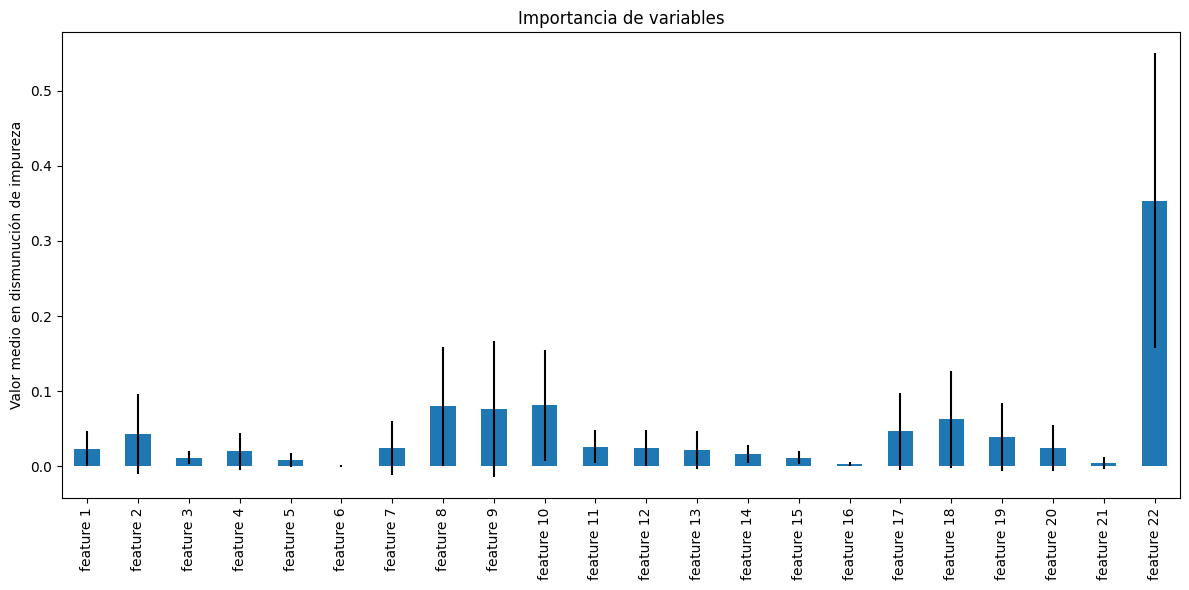

In [51]:
# entrenar random forest
from sklearn.ensemble import RandomForestClassifier
feature_names = [f"feature {i+1}" for i in range(x.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(x, y)
#obtener la importnacia de variables
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
# Graficar las importancia
fig, ax = plt.subplots(figsize = (12,6))
forest_importances = pd.Series(importances, index=feature_names)
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Importancia de variables")
ax.set_ylabel("Valor medio en dismunución de impureza")
fig.tight_layout()

In [52]:
#@title Pregunta Abierta
#@markdown ¿Son consistentes los resultados de los métodos?
respuesta = '' #@param {type:"string"}

In [ ]:
# completa con el mejor número de características
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

BEST_NUM_CARACTERISTICAS = 10
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
selector = RFE(estimator= LogisticRegression(),
              n_features_to_select=BEST_NUM_CARACTERISTICAS ,
              step=1)

estimators = [('normalización', StandardScaler()),
              ('Selección', selector),
              ('Clasificador',  LogisticRegression()),
              ]

pipe_selector = Pipeline(estimators)

pipe_selector.fit(X=X_train, y=y_train)

# se puede usar para predecir:
confusion_matrix(y_true = y_test , y_pred = pipe_selector.predict(X=X_test), normalize='true').ravel()

array([0.97897898, 0.01201201, 0.00900901, 0.09375   , 0.84375   ,
       0.0625    , 0.10344828, 0.17241379, 0.72413793])

In [3]:
## TEACHER
# --- CREATE or OVERWRITE STUDENTS NOTEBOOK ---
import init
from local.lib.rlxmoocapi import utils
student_notebook_fname = utils.convert_this_notebook_to_student()

<IPython.core.display.Javascript object>

NOTEBOOK name is lab6_parte1--XX--TEACHER--XX.ipynb
student notebook writen to 'lab6_parte1.ipynb'
